In [2]:
pip install pandas numpy matplotlib seaborn jupyter



   ------------- -------------------------- 2/6 [lark]
   ---------------------------------------- 6/6 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
sns.set_style("darkgrid")   #Adds Dark BAckground grid in Charts for Cleaner Visuals
plt.rcParams['figure.figsize']=(10,6)   # set default graph size width=10 and height =6

In [46]:
df=pd.read_csv("S:\Project for Job\Customer-Retention-Intelligence-System\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")   #reads CSV File

In [47]:
df.head()   #shows first 5 rows of Data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
df.info()   # Displays nuber of rows, cloumns, data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [49]:
df.describe()  # Generates Statistic for numeric columns

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [50]:
df.isnull().sum()  # Checks null valus and return count of all true values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [51]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')   #Converts values into numbers

In [52]:
df.dropna(inplace=True)  #Removes missing values

In [53]:
df.duplicated().sum()   #Checks DUplicate Values and retun count 

np.int64(0)

In [19]:
total_customers = df.shape[0]
print("Total Customers:", total_customers)

Total Customers: 7032


In [21]:
churn_rate = (df['Churn'].value_counts()['Yes']/total_customers)*100
print("Churn Rate:",round(churn_rate,2),"%")

Churn Rate: 26.58 %


In [22]:
average_revenue = df['MonthlyCharges'].mean()   # Calculates Average
print("Average Monthly Revenue:",round(average_revenue,2))  

Average Monthly Revenue: 64.8


In [54]:
df['Estimated_LTV'] = df['MonthlyCharges']* df['tenure']  # Created new column Estimated_LTV

In [55]:
df[['MonthlyCharges','tenure','Estimated_LTV']].head() # Displayed Columns

,MonthlyCharges,tenure,Estimated_LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [25]:
def risk_level(row):
    if row['MonthlyCharges']>80 and row['tenure']<12:
        return 'High Risk'
    elif row['MonthlyCharges']>50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

In [26]:
df['Risk_Level']= df.apply(risk_level, axis=1)

In [27]:
df[['MonthlyCharges', 'tenure','Risk_Level']].head()

,MonthlyCharges,tenure,Risk_Level
0,29.85,1,Low Risk
1,56.95,34,Medium Risk
2,53.85,2,Medium Risk
3,42.30,45,Low Risk
4,70.70,2,Medium Risk


In [28]:
def customer_segment(row):
    if row['Estimated_LTV'] > 5000:
        return 'High Value'
    elif row['tenure'] > 50:
        return 'Loyal Customer'
    else:
        return 'Standard Customer'

In [31]:
df["Customer_Type"]=df.apply(customer_segment, axis=1)

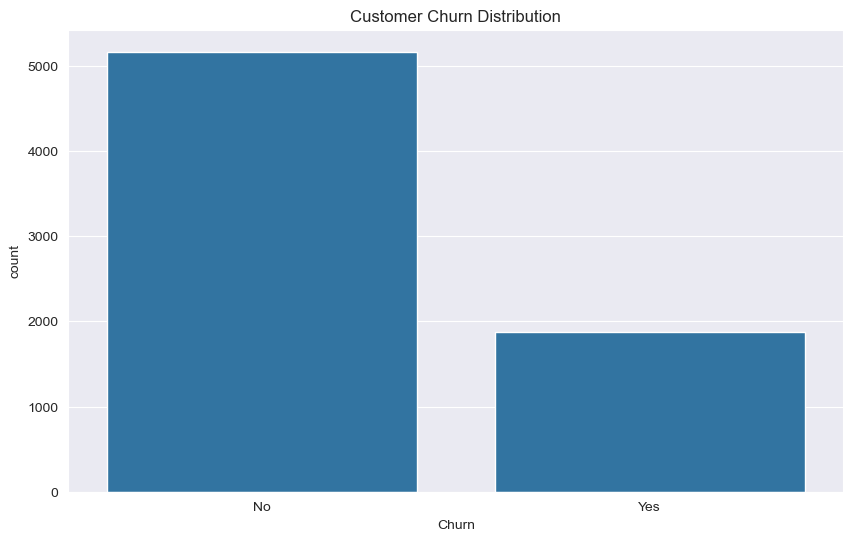

In [33]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

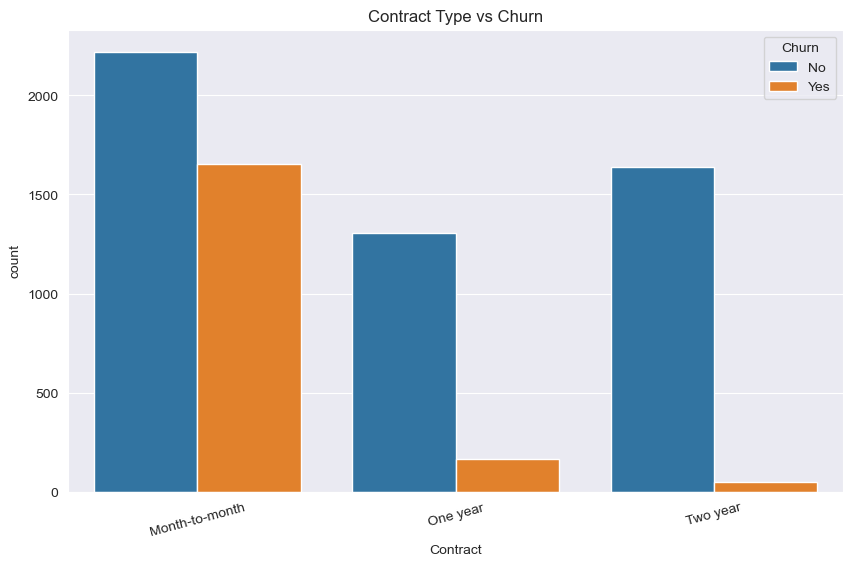

In [34]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)
plt.show()

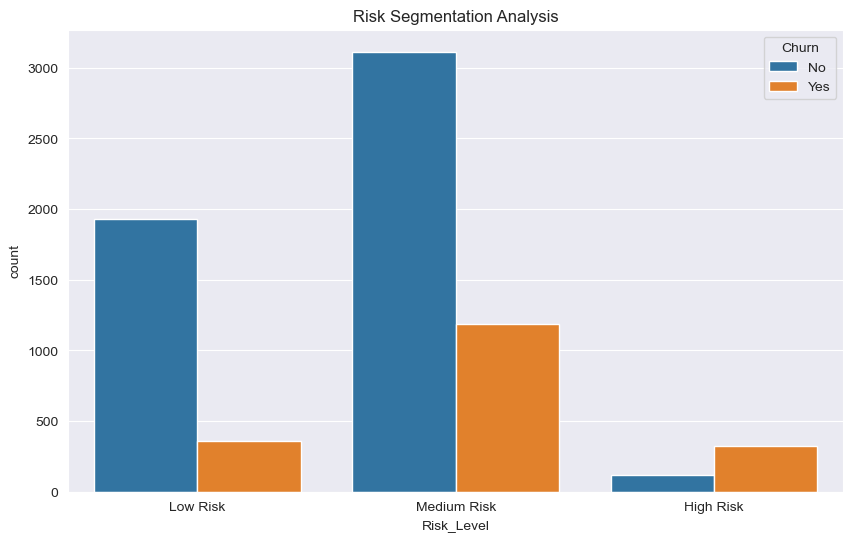

In [35]:
sns.countplot(
    x='Risk_Level',
    hue='Churn',
    data=df
)
plt.title('Risk Segmentation Analysis')
plt.show()

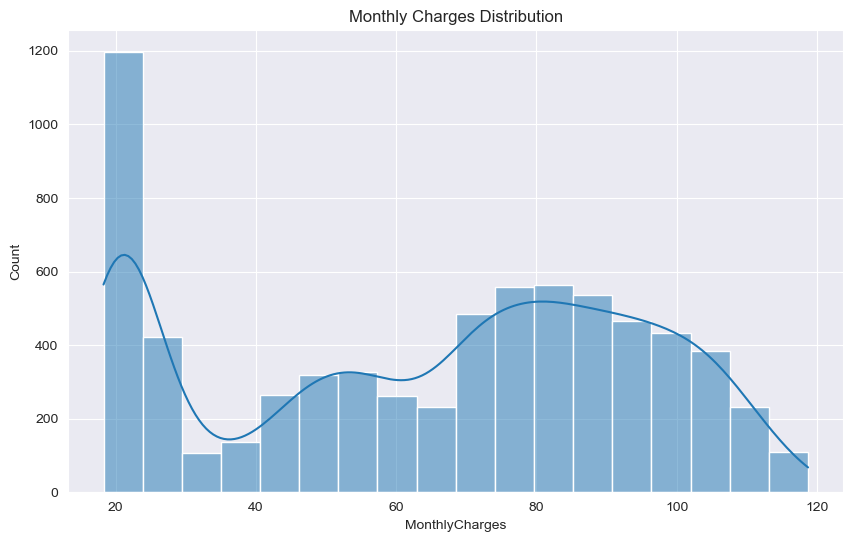

In [36]:
sns.histplot(
    data =df,
    x='MonthlyCharges',
    kde=True
)
plt.title('Monthly Charges Distribution')
plt.show()

In [38]:
churned_customers =df[df['Churn']=='Yes']
revenue_loss = churned_customers['MonthlyCharges'].sum()
print("Monthly Revenue Loss:",revenue_loss)

Monthly Revenue Loss: 139130.85


In [39]:
high_value_churn=df[
    (df['Customer_Type']=='Hogh Value')&
    (df['Churn']=='Yes')
]
print(high_value_churn.shape[0])

0


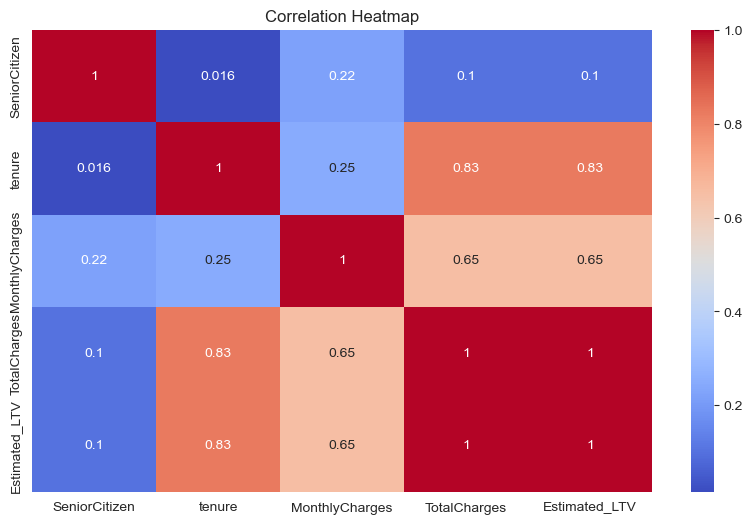

In [41]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [56]:
df.to_csv("S:/Project for Job/Customer-Retention-Intelligence-System/dashboards/cleaned_customer_data.csv", index=False)   # Exports Cleaned data 

In [57]:
plt.savefig("S:/Project for Job/Customer-Retention-Intelligence-System/visuals/churn_chart.png")   #saves charts in folder

<Figure size 1000x600 with 0 Axes>

#### Business Insights

Customers with month-to-month contracts show significantly higher churn rates.

High monthly charges are associated with increased churn probability.

High-value customers contribute major revenue loss when they churn.

#### Business Recommendations

1. Offer discounts for long-term contracts.

2. Target high-risk customers with retention campaigns.

3. Provide loyalty benefits for premium customers.

4. Reduce churn among high-value customers through personalized support.